# Work Planning Prototype

**Background**: In our previous notebooks, we have a collection of techniques for performing, allocating, and analyzing our work. We anticipate that the scope of work will be greater than our hardware's ability to complete in a single charge. We should therefore carefully plan the work we aim to do in advance of arriving at a work site so that we come much more prepared.


Perhaps we follow a plan like:
- Prepare region image
    - Consolidate to single geotiff
    - Re-project CRS
    - Filter, smooth, simplify, downsample
- Parition region into manageable pieces
    - Call them "work areas/sites/plots", e.g. 1/2 acre spaces
- Segmentation & masking?
- Plan macro/micro routes
    - Macro: 1/2 acre work spaces
    - Micro: route between plants in a work space
- Execute? Store execution results? Analyze performance?


## Prepare Region Image

- Consolidate to single geotiff
- Reproject CRS
- Image pre-processing

In [1]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'

# file_path = '../input/IGNORE_Brewster-ortho.tif'
file_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'


Image CRS - EPSG:32613


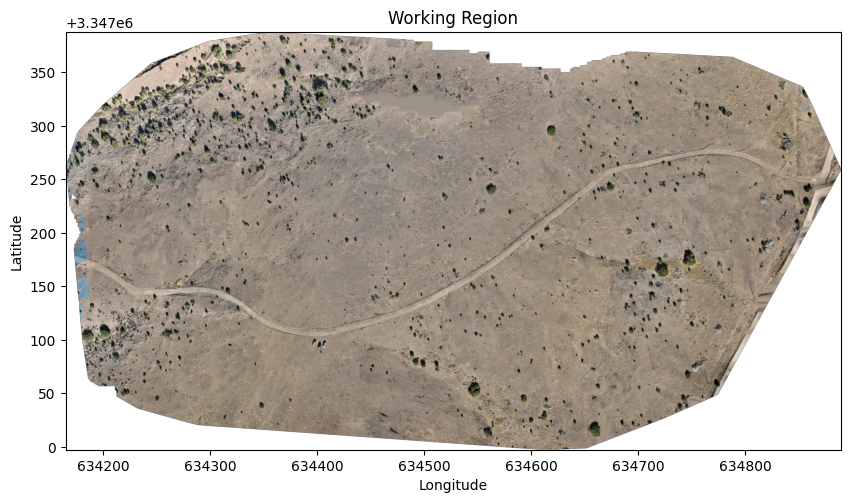

Image dimensions: (3535, 6559, 4)


In [2]:
from plant_search.load_image import load_image, plot_image, plot_geotiff

ds = 2 # downscale ratio

image, transform, bounds = load_image(file_path)

# We have a georeferenced image
if image is not None and transform and bounds:
    image = image[::ds, ::ds]
    # Calculate extent in geographic coordinates
    image_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    plot_geotiff(image, transform, bounds, "Working Region")

# We have image, but not georeferenced
elif image is not None and bounds:
    height, width = image.shape[:2]
    image_extent = (0, width, 0, height)
    image = image[::ds, ::ds]
    plot_image(image, "Original Image")

print(f"Image dimensions: {image.shape}")

In [3]:
# Reproject region to geographic CRS
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling


def reproject_to_meters_optimized(src_path, dst_path, target_crs=None):
    """Reproject the GeoTIFF to a CRS with meters, matching the original resolution and applying compression."""
    with rasterio.open(src_path) as src:
        # Set target CRS (default: UTM based on the image center)
        if target_crs is None:
            centroid = ((src.bounds.left + src.bounds.right) / 2, 
                        (src.bounds.top + src.bounds.bottom) / 2)
            utm_zone = int((centroid[0] + 180) // 6) + 1
            is_northern = centroid[1] >= 0
            target_crs = f"EPSG:{32600 + utm_zone if is_northern else 32700 + utm_zone}"
        
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
        
        # Match resolution to the original
        dst_resolution = (src.res[0], src.res[1])
        width = int((src.bounds.right - src.bounds.left) / dst_resolution[0])
        height = int((src.bounds.top - src.bounds.bottom) / dst_resolution[1])
        
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': target_crs,
            'transform': transform,
            'width': width,
            'height': height,
            'compress': 'lzw'  # Add compression
        })
        
        with rasterio.open(dst_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=Resampling.nearest  # Use nearest neighbor for speed
                )
    return dst_path


## Parition Region
- Create outline polygon of full work region
    - Simplify geometry for faster execution
- Divide full region into working areas

In [4]:
region_crs = 32613 # Use this everywhere for consistency

simplification_tolerance = 5

# Convert target area to square meters
target_area_acres = 0.5

max_iterations = 15

Reached maximum iterations without full convergence.


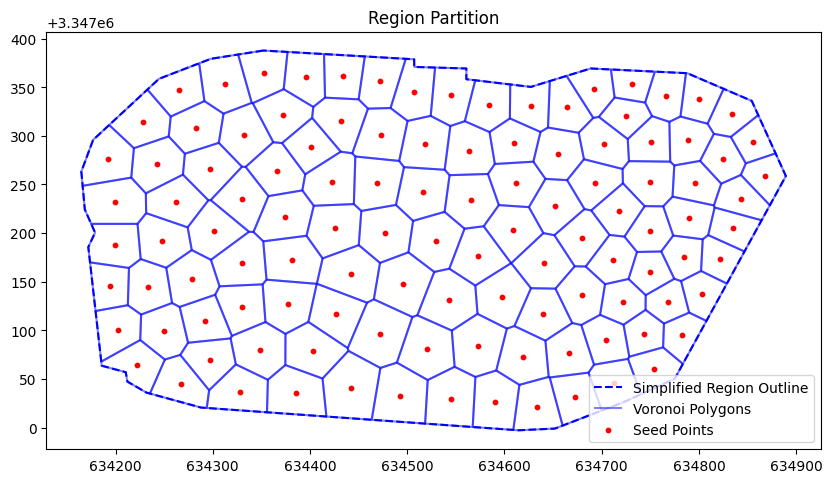

In [5]:
from plant_search.region_partition import (
    extract_region_contour,
    simplify_polygon,
    generate_voronoi_partition,
    centroidal_voronoi_tessellation,
)
import matplotlib.pyplot as plt
import geopandas as gpd


region_contour_gpd = extract_region_contour(file_path)
contour_gdf_projected = region_contour_gpd.to_crs(epsg=region_crs)  # Example: UTM Zone 14N
simplified_polygon = simplify_polygon(contour_gdf_projected.geometry.iloc[0], simplification_tolerance)

target_area_sqm = target_area_acres * 4046.86
num_points = int(simplified_polygon.area / target_area_sqm)

# voronoi_gdf, points_gdf = generate_voronoi_partition(simplified_polygon, num_points)
voronoi_gdf, points_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_points, max_iterations)


fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
voronoi_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Polygons")
points_gdf.plot(ax=ax, color="red", markersize=10, label="Seed Points")
plt.legend()
plt.title("Region Partition")
plt.show()

## Macro Planning

Since we have divided our working region into smaller, more manageable portions, we can now plan our approach. We will use our cells to help measure area completion and divide work areas more efficiently. 

This section is concerned with:
- clustering of cells into trips
- prioritization of cells
- global trip efficiency
    - A.K.A. Multi-Trip Routing Problem (MTRP)
- Completion efficiency

Our planning inputs:
- cells and centroids
- base station location
    - where drones launch and land
- drone battery range
- target density per cell

In [6]:
# Cells
points_gdf

# Base station location
base_station = (0,0)

# Drone battery range
trip_range = 500 # meters

# Cell densities


### Calculate Cell Densities

First-pass system to determine:
- Number of targets in each cell
- Distance to traverse all targets in each cell

In [7]:
from plant_search.image_preprocess import (
    generate_target_mask,
    identify_targets,
)

binary_mask = generate_target_mask(image) # Generate

# Load mask the easy way
binary_mask_path = "../outputs/region_binary_mask.tif"

# Open the GeoTIFF and load as NumPy array
with rasterio.open(binary_mask_path) as src:
    binary_mask = src.read(1)  # Read the first band
    transform = src.transform  # Get the affine transform
    crs = src.crs  # Get the CRS


# targets_gdf = identify_targets(binary_mask, transform)

# print(f"Number of targets (detected plants): {len(targets_gdf)}")

In [ ]:
# # Instead of re-computing, save to image
# binary_mask_scaled = (binary_mask * 255).astype("uint8")

# with rasterio.open(file_path) as src:
#     image_region_crs = src.crs

# # Save the georeferenced binary mask with the correct scaling
# with rasterio.open(
#     "../outputs/region_binary_mask.tif",
#     "w",
#     driver="GTiff",
#     height=binary_mask.shape[0],
#     width=binary_mask.shape[1],
#     count=1,
#     dtype="uint8",
#     crs=image_region_crs,
#     transform=transform,
# ) as dst:
#     dst.write(binary_mask_scaled, 1)

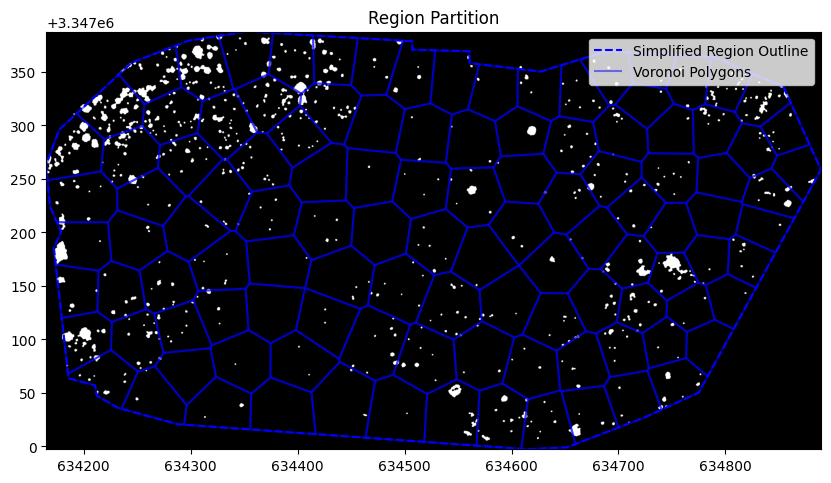

In [13]:

# Display identified targets
fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(image, extent=image_extent, alpha=0.8) # Display original image
ax.imshow(binary_mask, extent=image_extent, cmap='gray')

# Region outline
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
# Region cells
voronoi_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Polygons")
# points_gdf.plot(ax=ax, color="red", markersize=10, label="Seed Points")

# Plot targets bounding boxes
# targets_gdf.plot(column='bounding_box', ax=ax, edgecolor='red', facecolor='none', linewidth=1.5, label='Bounding Boxes')
# Plot targets centroids
# targets_gdf = targets_gdf.set_geometry('geometry')
# targets_gdf.plot(ax=ax, color='blue', markersize=10, label='Centroids')



# for bbox, centroid in zip(bounding_boxes, centroids):
#     (min_col, min_row), (max_col, max_row) = bbox # Draw bounding box
#     ax.add_patch(plt.Rectangle((min_col, min_row), max_col - min_col, max_row - min_row,
#                                 edgecolor="red", fill=False, linewidth=1))
#     ax.plot(centroid[0], centroid[1], "ro", markersize=2)  # Plot centroid

plt.legend()
plt.title("Region Partition")
plt.show()

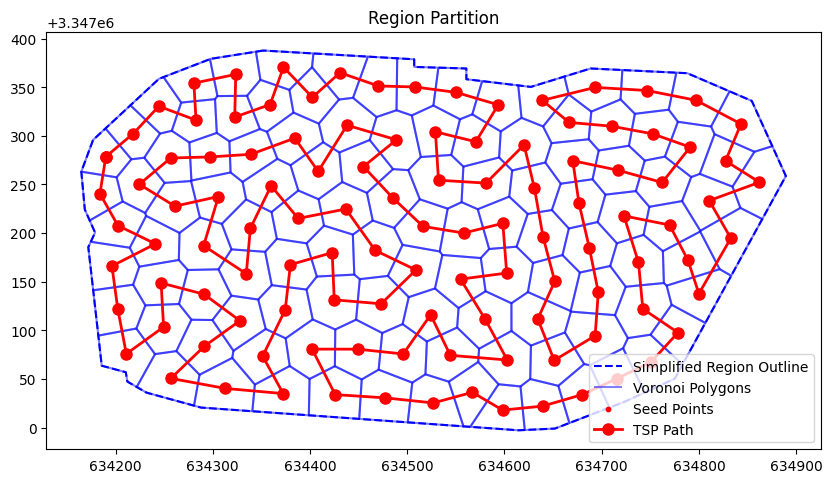

In [9]:
from plant_search.pathfinding import (
    compute_tsp_path,
    calculate_optimal_route,
    calculate_total_distance,
    plot_tsp_path_on_image,
)
import matplotlib.pyplot as plt



# points_gdf
plot_centroids = points_gdf.geometry
plot_coords_list = [(point.x, point.y) for point in plot_centroids]
# path = compute_tsp_path(plot_coords_list)
path = calculate_optimal_route(plot_coords_list)

fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
voronoi_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Polygons")
points_gdf.plot(ax=ax, color="red", markersize=10, label="Seed Points")

# Overlay the TSP path
ordered_centroids = [plot_coords_list[i] for i in path]
x, y = zip(*ordered_centroids)
plt.plot(x, y, 'o-', color='red', label='TSP Path', markersize=8, linewidth=2)

plt.legend()
plt.title("Region Partition")
plt.show()


## Micro Planning

Perform image analysis on each smaller section of our greater region.

In [10]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping

# Path to the original image
# raster_path = "path_to_your_image.tif"

# Example: Select a Voronoi polygon by an attribute or ID
selected_partition = voronoi_gdf[voronoi_gdf['id'] == 0]


# Convert the selected polygon to GeoJSON-like format
# geometry = [mapping(selected_partition.geometry.iloc[0])]

# # Open the raster and clip it
# with rasterio.open(file_path) as src:
#     out_image, out_transform = mask(src, geometry, crop=True)
#     out_meta = src.meta.copy()

# # Update metadata for the clipped section
# out_meta.update({
#     "driver": "GTiff",
#     "height": out_image.shape[1],
#     "width": out_image.shape[2],
#     "transform": out_transform
# })
